# Stage 2.5 — EDA on Raw Data

## Exploratory Data Analysis Using Raw Waveforms and Generator Labels

This notebook performs EDA on the **original (raw) dataset** before preprocessing. It uses raw audio waveforms and the **Generator** (TTS model) information that is lost after preprocessing. Plots here complement `03_eda_acoustic_features.ipynb`, which works with extracted acoustic features.

**Requires:** Raw data in `data/raw/` (run `python download_dataset.py` first).

**Pipeline order:** 02 (dataset understanding) → **02.5 (this notebook)** → 03 (acoustic features EDA).

## 1. Setup and Build DataFrames

We scan the raw data to build two DataFrames:
- **df_stat**: per-file metadata (Generator, Label, Duration, Sample_Rate, etc.) for sample count and duration plots.
- **df**: minimal DataFrame with `file_path`, `Generator`, `Label` for waveform-based analyses (amplitude dist, Mel spectrogram, rolloff, t-SNE, etc.).

In [5]:
import os
import sys
from pathlib import Path

import librosa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import soundfile as sf
from scipy import signal
from sklearn.manifold import TSNE

PROJECT_ROOT = Path("..")
sys.path.insert(0, str(PROJECT_ROOT))

from config import RAW_DATA_DIR

AUDIO_EXTENSIONS = {'.wav', '.mp3'}
SAMPLE_RATE = 16000


def load_audio(path, sr=16000):
    """Load audio with soundfile, resample if needed. Returns (y, sr)."""
    y, orig_sr = sf.read(path, dtype='float32')
    if y.ndim > 1:
        y = y.mean(axis=1)
    if orig_sr != sr:
        n = int(len(y) * sr / orig_sr)
        y = signal.resample(y, n).astype(np.float32)
    return y, sr

In [6]:
def get_audio_specs(path):
    """Extract audio specs using soundfile."""
    try:
        info = sf.info(str(path))
        return {
            "Sample_Rate": info.samplerate,
            "Channels": info.channels,
            "Duration_Sec": info.duration,
            "Status": "OK"
        }
    except Exception as e:
        return {"Status": f"Error: {str(e)}"}


def scan_dataset(root):
    """Scan raw data; preserve Generator (folder name) and Label."""
    all_stats = []
    all_paths = []

    for folder in os.listdir(root):
        folder_path = Path(root) / folder
        if not folder_path.is_dir():
            continue
        label = 'Real' if 'real' in folder.lower() else 'Fake'
        files = [f for f in os.listdir(folder_path) if Path(f).suffix.lower() in AUDIO_EXTENSIONS]
        print(f"Scanning {folder}... ({len(files)} files)")

        for f in files:
            f_path = folder_path / f
            f_size = f_path.stat().st_size
            if f_size == 0:
                all_stats.append({'Generator': folder, 'Label': label, 'Status': 'Missing/0KB'})
                continue
            meta = get_audio_specs(f_path)
            all_stats.append({
                'Generator': folder, 'Label': label, 'file_path': str(f_path),
                'Size_KB': f_size / 1024, **meta
            })
            all_paths.append({'file_path': str(f_path), 'Generator': folder, 'Label': label})

    df_stat = pd.DataFrame(all_stats)
    df = pd.DataFrame(all_paths)
    return df_stat, df


if not RAW_DATA_DIR.exists():
    raise FileNotFoundError("Raw data not found. Run: python download_dataset.py")

df_stat, df = scan_dataset(RAW_DATA_DIR)
print(f"\ndf_stat: {len(df_stat)} rows; df: {len(df)} rows")

Scanning NaturalSpeech3... (32 files)
Scanning FlashSpeech... (118 files)
Scanning seedtts_files... (599 files)
Scanning VALLE... (95 files)
Scanning PromptTTS2... (25 files)
Scanning xTTS... (600 files)
Scanning VoiceBox... (104 files)
Scanning real_samples... (2274 files)
Scanning OpenAI... (600 files)

df_stat: 4447 rows; df: 4447 rows


## 2. Sample Count per Folder and Duration Distribution

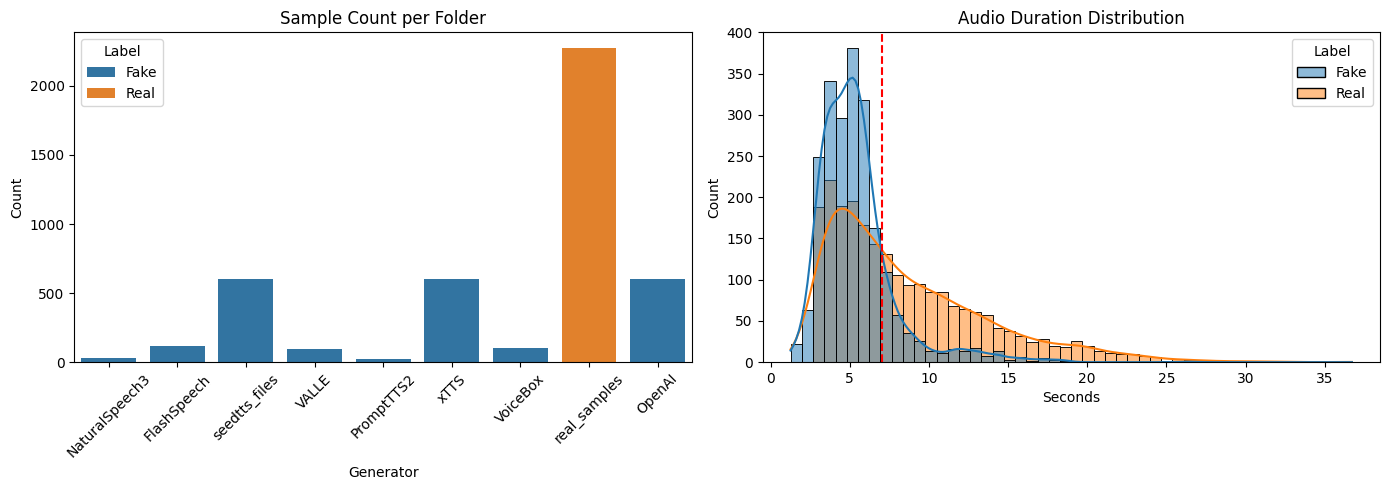

In [7]:
def plot_presentation_visuals(df_stat):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    sns.countplot(data=df_stat, x='Generator', hue='Label', ax=ax1)
    ax1.set_title("Sample Count per Folder")
    ax1.set_xlabel("Generator")
    ax1.set_ylabel("Count")
    ax1.tick_params(axis='x', rotation=45)

    valid = df_stat[df_stat['Status'] == 'OK']
    if 'Duration_Sec' in valid.columns and len(valid) > 0:
        sns.histplot(data=valid, x='Duration_Sec', hue='Label', bins=50, kde=True, ax=ax2)
        ax2.axvline(valid['Duration_Sec'].mean(), color='red', linestyle='--', label='Mean')
    ax2.set_title("Audio Duration Distribution")
    ax2.set_xlabel("Seconds")
    ax2.set_ylabel("Count")
    plt.tight_layout()
    plt.show()


plot_presentation_visuals(df_stat)

## 3. Average Amplitude Distribution (Log Scale)

Real vs Fake average amplitude histogram. Differences near zero (noise floor) can reveal quantization or processing artifacts.

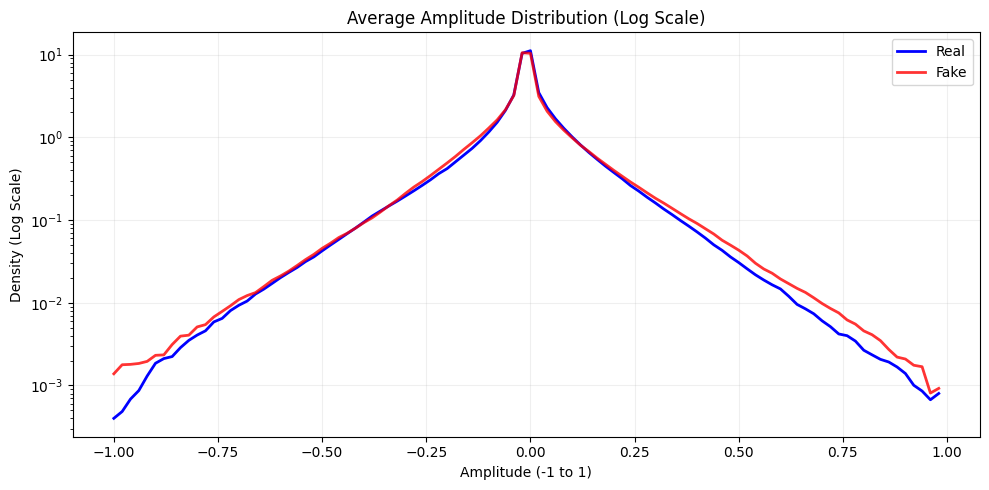

In [8]:
def get_avg_amplitude_dist(df, label_name, num_samples=100):
    subset = df[df['Label'] == label_name].sample(n=min(num_samples, len(df)), random_state=42)
    bins = np.linspace(-1, 1, 101)
    all_histograms = []
    for path in subset['file_path']:
        try:
            waveform, _ = load_audio(path)
            waveform = waveform / (np.abs(waveform).max() + 1e-8)
            counts, _ = np.histogram(waveform.flatten(), bins=bins, density=True)
            all_histograms.append(counts)
        except Exception:
            continue
    return np.mean(all_histograms, axis=0), bins


plt.figure(figsize=(10, 5))
real_mean, bins = get_avg_amplitude_dist(df, 'Real')
fake_mean, _ = get_avg_amplitude_dist(df, 'Fake')
plt.plot(bins[:-1], real_mean, label='Real', color='blue', lw=2)
plt.plot(bins[:-1], fake_mean, label='Fake', color='red', lw=2, alpha=0.8)
plt.yscale('log')
plt.title("Average Amplitude Distribution (Log Scale)")
plt.xlabel("Amplitude (-1 to 1)")
plt.ylabel("Density (Log Scale)")
plt.legend()
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

## 4. Average Mel-Spectrogram (Real vs Fake)

Average mel-spectrogram over sampled files. Synthetic audio may show different spectral patterns.

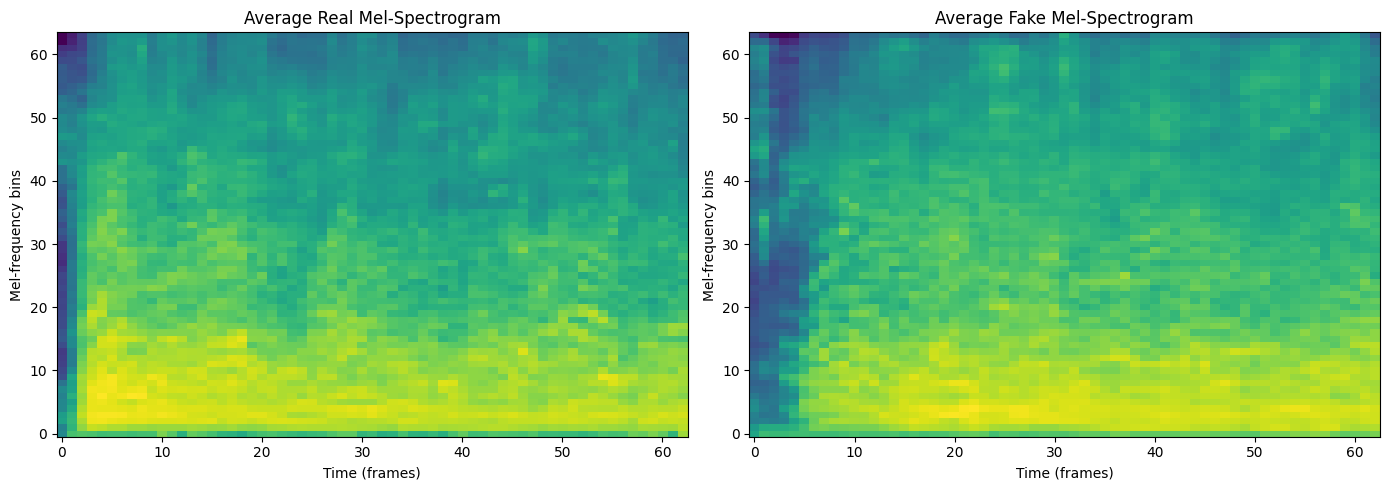

In [9]:
def get_average_spec(file_paths, n_samples=100):
    specs = []
    for p in file_paths[:n_samples]:
        y, sr = load_audio(p)
        y = y[:32000] if len(y) > 32000 else np.pad(y, (0, 32000 - len(y)))
        mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=64, n_fft=1024, hop_length=512)
        specs.append(mel)
    return np.mean(specs, axis=0)


real_paths = df[df['Label'] == 'Real']['file_path'].tolist()
fake_paths = df[df['Label'] == 'Fake']['file_path'].tolist()
real_avg = get_average_spec(real_paths)
fake_avg = get_average_spec(fake_paths)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.imshow(librosa.power_to_db(real_avg), aspect='auto', origin='lower')
ax1.set_title("Average Real Mel-Spectrogram")
ax1.set_xlabel("Time (frames)")
ax1.set_ylabel("Mel-frequency bins")
ax2.imshow(librosa.power_to_db(fake_avg), aspect='auto', origin='lower')
ax2.set_title("Average Fake Mel-Spectrogram")
ax2.set_xlabel("Time (frames)")
ax2.set_ylabel("Mel-frequency bins")
plt.tight_layout()
plt.show()

## 5. Mel-Spectrogram Delta (Temporal Movement)

Delta of mel-spectrogram shows how the spectrum changes over time. Synthetic speech may exhibit different temporal dynamics.

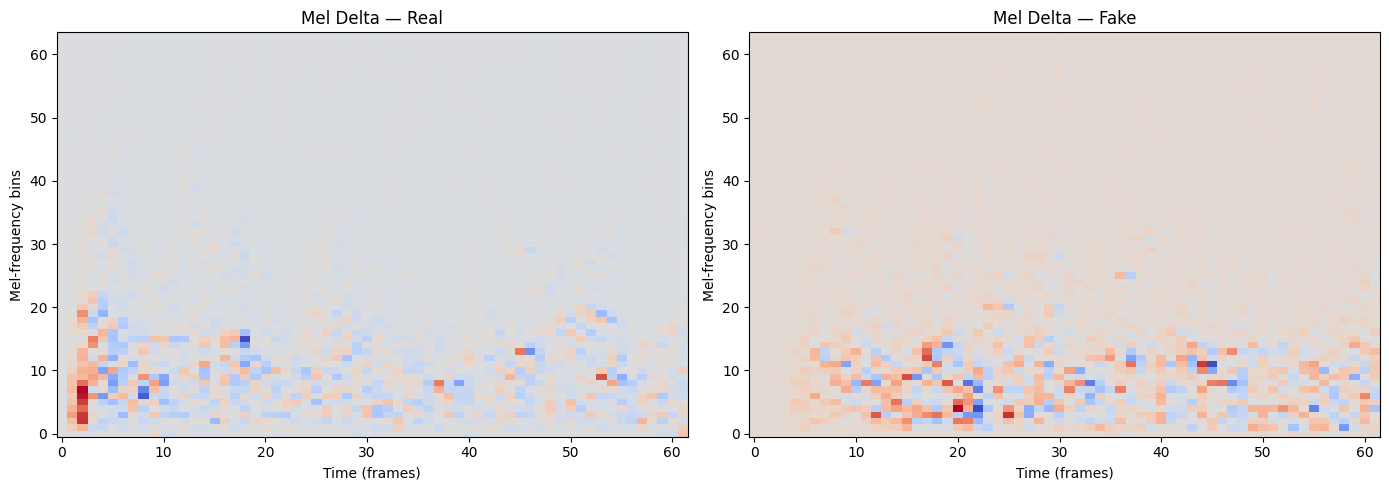

In [10]:
def get_delta_spec(spec):
    return np.diff(spec, axis=1)


real_delta = get_delta_spec(real_avg)
fake_delta = get_delta_spec(fake_avg)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.imshow(real_delta, aspect='auto', cmap='coolwarm', origin='lower')
ax1.set_title("Mel Delta — Real")
ax1.set_xlabel("Time (frames)")
ax1.set_ylabel("Mel-frequency bins")
ax2.imshow(fake_delta, aspect='auto', cmap='coolwarm', origin='lower')
ax2.set_title("Mel Delta — Fake")
ax2.set_xlabel("Time (frames)")
ax2.set_ylabel("Mel-frequency bins")
plt.tight_layout()
plt.show()

## 6. Spectral Rolloff: Real vs Fake and by Generator

85% energy threshold frequency. Rolloff ceiling per TTS model.

/var/folders/d6/5zb006x52c93tzts24rsbvv80000gn/T/ipykernel_64300/2745855224.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  subset = df.groupby('Label', group_keys=False).apply(lambda g: g.sample(n=min(n_samples, len(g)), random_state=42))
/var/folders/d6/5zb006x52c93tzts24rsbvv80000gn/T/ipykernel_64300/2745855224.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=rolloff_df, x='Label', y='Spectral_Rolloff_Hz', palette='Set2', ax=ax1)
/var/folders/d6/5zb006x52c93tzts24rsbvv80000gn/T/ipykernel_64300/2745855224.py:23: UserWarning: set_ticklabel

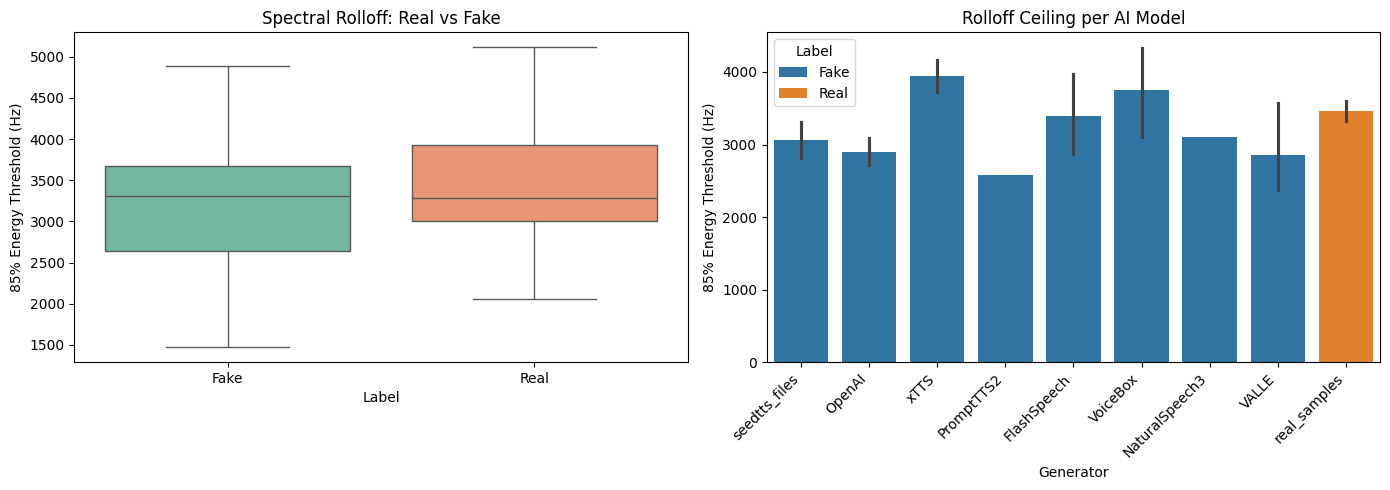

In [11]:
def get_rolloff_stats(df, n_samples=100, roll_percent=0.85):
    subset = df.groupby('Label', group_keys=False).apply(lambda g: g.sample(n=min(n_samples, len(g)), random_state=42))
    results = []
    for _, row in subset.iterrows():
        try:
            y, sr = load_audio(row['file_path'])
            rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr, n_fft=1024, roll_percent=roll_percent)
            rolloff_hz = rolloff.mean()
            results.append({'Label': row['Label'], 'Generator': row['Generator'], 'Spectral_Rolloff_Hz': float(rolloff_hz)})
        except Exception:
            continue
    return pd.DataFrame(results)


rolloff_df = get_rolloff_stats(df)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=rolloff_df, x='Label', y='Spectral_Rolloff_Hz', palette='Set2', ax=ax1)
ax1.set_title("Spectral Rolloff: Real vs Fake")
ax1.set_xlabel("Label")
ax1.set_ylabel("85% Energy Threshold (Hz)")
sns.barplot(data=rolloff_df, x='Generator', y='Spectral_Rolloff_Hz', hue='Label', ax=ax2)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')
ax2.set_title("Rolloff Ceiling per AI Model")
ax2.set_xlabel("Generator")
ax2.set_ylabel("85% Energy Threshold (Hz)")
plt.tight_layout()
plt.show()

## 7. Spectral Centroid by Generator

Frequency centre of gravity (brightness) per TTS model.

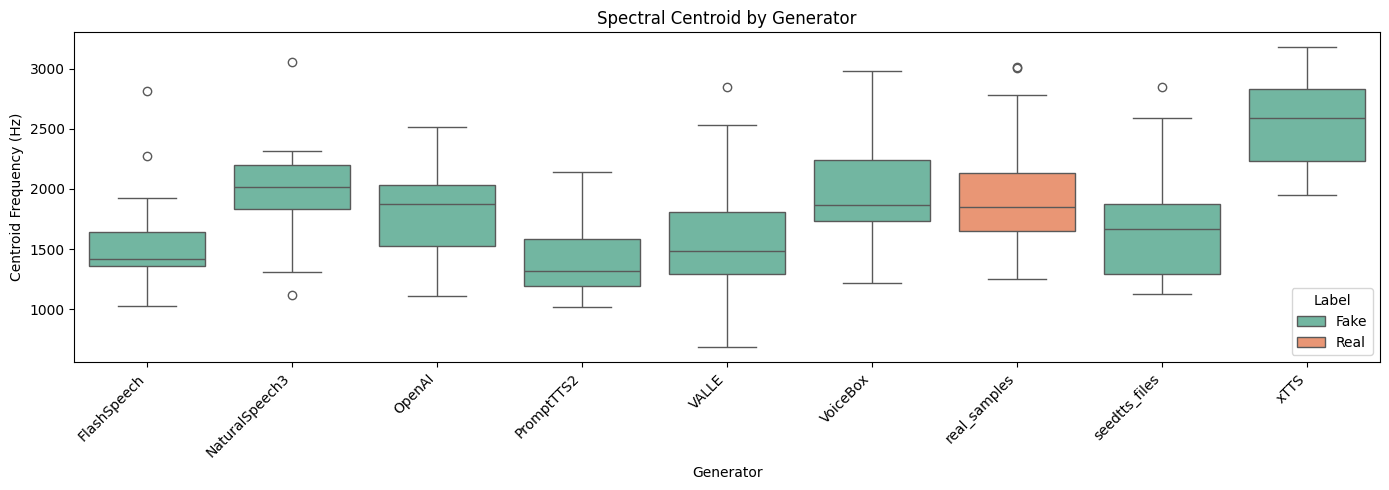

In [12]:
def get_generator_stats(df, samples_per_gen=30):
    all_results = []
    for generator, group in df.groupby('Generator'):
        subset = group.sample(n=min(len(group), samples_per_gen), random_state=42)
        for path in subset['file_path']:
            try:
                y, sr = load_audio(path)
                y = y / (np.abs(y).max() + 1e-8)
                c = librosa.feature.spectral_centroid(y=y, sr=sr, n_fft=1024)
                all_results.append({'Generator': generator, 'Label': group['Label'].iloc[0], 'Avg_Centroid': float(c.mean())})
            except Exception:
                continue
    return pd.DataFrame(all_results)


stats_df = get_generator_stats(df)

plt.figure(figsize=(14, 5))
sns.boxplot(data=stats_df, x='Generator', y='Avg_Centroid', hue='Label', palette='Set2')
plt.xticks(rotation=45, ha='right')
plt.title("Spectral Centroid by Generator")
plt.xlabel("Generator")
plt.ylabel("Centroid Frequency (Hz)")
plt.tight_layout()
plt.show()

## 8. Zero Crossing Rate (ZCR) Distribution

ZCR reflects high-frequency content and noisiness. Synthetic audio may have different ZCR profiles.

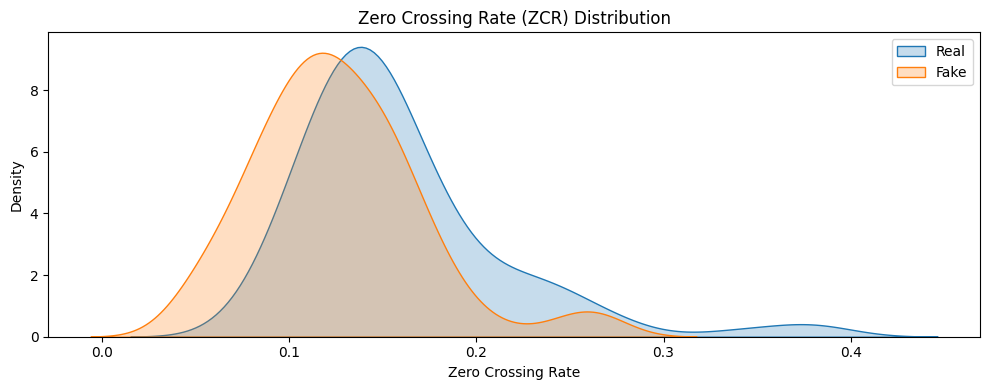

In [13]:
def plot_zcr_comparison(file_paths, label, n=100):
    zcrs = []
    for p in file_paths[:n]:
        y, _ = load_audio(p)
        zcr = np.mean(np.abs(np.diff(np.sign(y)))) / 2
        zcrs.append(zcr)
    sns.kdeplot(zcrs, label=label, fill=True)


plt.figure(figsize=(10, 4))
plot_zcr_comparison(df[df['Label'] == 'Real']['file_path'].tolist(), 'Real')
plot_zcr_comparison(df[df['Label'] == 'Fake']['file_path'].tolist(), 'Fake')
plt.title("Zero Crossing Rate (ZCR) Distribution")
plt.xlabel("Zero Crossing Rate")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

## 9. t-SNE Clustering (Colored by Label, Styled by Generator)

MFCC-based embedding with label and generator visualization.

/var/folders/d6/5zb006x52c93tzts24rsbvv80000gn/T/ipykernel_64300/2139770876.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  subset = df.groupby('Label', group_keys=False).apply(lambda g: g.sample(n=min(n_samples // 2, len(g)), random_state=42))


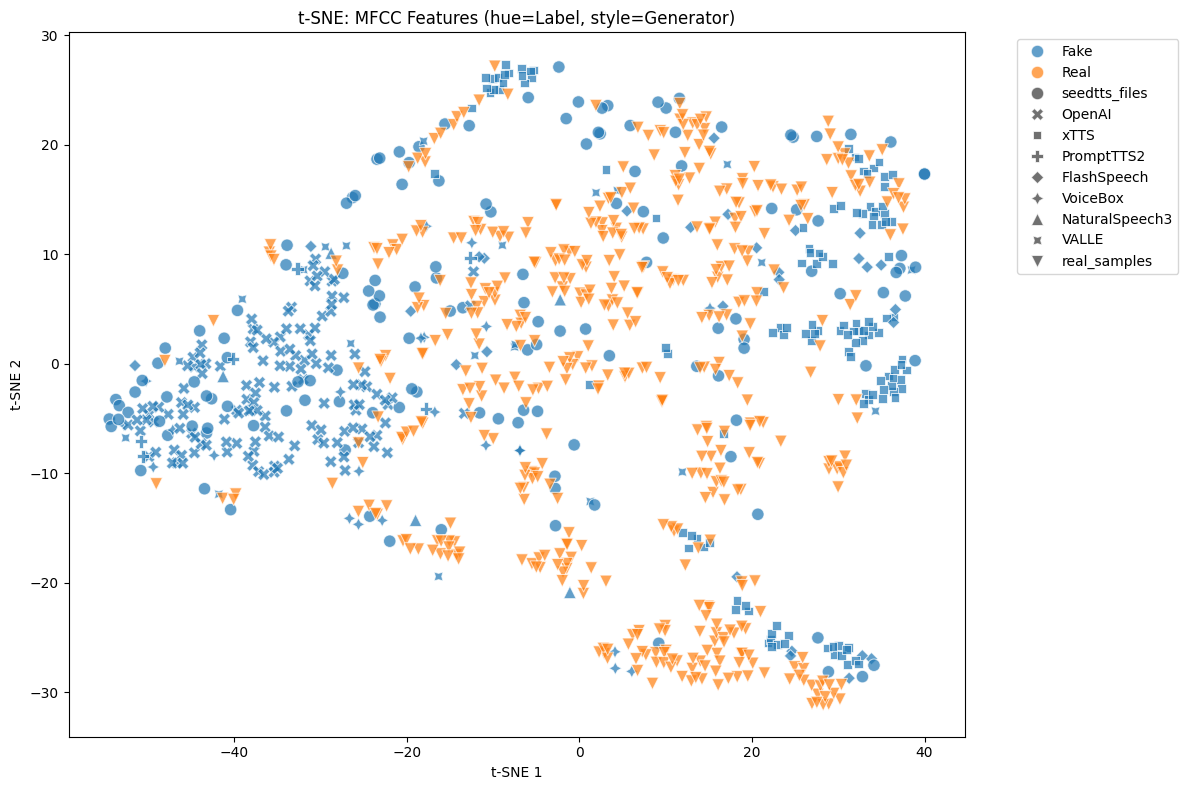

In [14]:
def extract_features_for_tsne(df, n_samples=1000):
    subset = df.groupby('Label', group_keys=False).apply(lambda g: g.sample(n=min(n_samples // 2, len(g)), random_state=42))
    features = []
    for path in subset['file_path']:
        y, sr = load_audio(path)
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13, n_fft=400, hop_length=160, n_mels=23)
        features.append(np.mean(mfcc, axis=1))
    return np.array(features), subset['Label'].values, subset['Generator'].values


X, y_labels, y_generators = extract_features_for_tsne(df)
tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
X_embedded = tsne.fit_transform(X)

plt.figure(figsize=(12, 8))
sns.scatterplot(x=X_embedded[:, 0], y=X_embedded[:, 1], hue=y_labels, style=y_generators, s=80, alpha=0.7, palette={'Real': 'blue', 'Fake': 'orange'})
plt.title("t-SNE: MFCC Features (hue=Label, style=Generator)")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 10. Summary

This notebook explored raw audio with **Generator** awareness. Key observations:
- **Sample count & duration**: Distribution across TTS models and real samples.
- **Amplitude distribution**: Noise-floor differences between real and synthetic.
- **Mel spectrogram & delta**: Spectral and temporal structure.
- **Rolloff & centroid by Generator**: Per-model forensic fingerprints.
- **ZCR**: High-frequency / noisiness profile.
- **t-SNE**: Clustering with both label and generator visibility.

Next: **03_eda_acoustic_features.ipynb** for extracted-feature EDA.